# LOADING DATASET

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./london_energy.csv")
print(df.isna().sum())
df.head()

LCLid    0
Date     0
KWH      0
dtype: int64


,LCLid,Date,KWH
0,MAC000002,2012-10-12,7.098
1,MAC000002,2012-10-13,11.087
2,MAC000002,2012-10-14,13.223
3,MAC000002,2012-10-15,10.257
4,MAC000002,2012-10-16,9.769


In [2]:
df_avg_consumption = df.groupby("Date")["KWH"].mean()
df_avg_consumption = pd.DataFrame({"date": df_avg_consumption.index.tolist(), "consumption": df_avg_consumption.values.tolist()})
df_avg_consumption["date"] = pd.to_datetime(df_avg_consumption["date"])
print(f"From: {df_avg_consumption['date'].min()}")
print(f"To: {df_avg_consumption['date'].max()}")

From: 2011-11-23 00:00:00
To: 2014-02-28 00:00:00


<Axes: xlabel='date'>

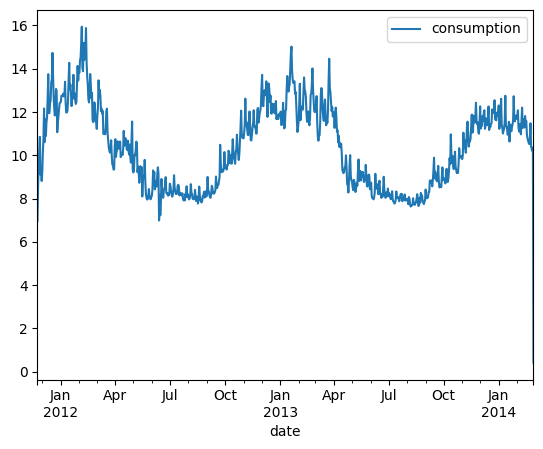

In [3]:
df_avg_consumption.plot(x="date", y="consumption")

<Axes: xlabel='date'>

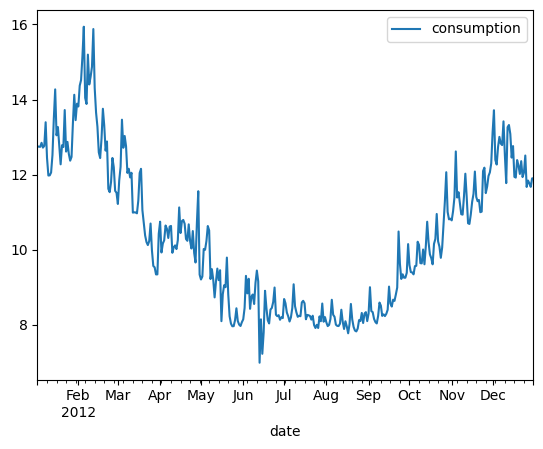

In [4]:
df_avg_consumption.query("date > '2012-01-01' & date < '2013-01-01'").plot(x="date", y="consumption")


In [5]:
df_avg_consumption["day_of_week"] = df_avg_consumption["date"].dt.dayofweek
df_avg_consumption["day_of_year"] = df_avg_consumption["date"].dt.dayofyear
df_avg_consumption["month"] = df_avg_consumption["date"].dt.month
df_avg_consumption["quarter"] = df_avg_consumption["date"].dt.quarter
df_avg_consumption["year"] = df_avg_consumption["date"].dt.year

df_avg_consumption.head()

,date,consumption,day_of_week,day_of_year,month,quarter,year
0,2011-11-23,6.952692,2,327,11,4,2011
1,2011-11-24,8.536480,3,328,11,4,2011
2,2011-11-25,9.499781,4,329,11,4,2011
3,2011-11-26,10.267707,5,330,11,4,2011
4,2011-11-27,10.850805,6,331,11,4,2011


In [6]:
training_mask = df_avg_consumption["date"] < "2013-07-28"
training_data = df_avg_consumption.loc[training_mask]
print(training_data.shape)

testing_mask = df_avg_consumption["date"] >= "2013-07-28"
testing_data = df_avg_consumption.loc[testing_mask]
print(testing_data.shape)

(613, 7)
(216, 7)


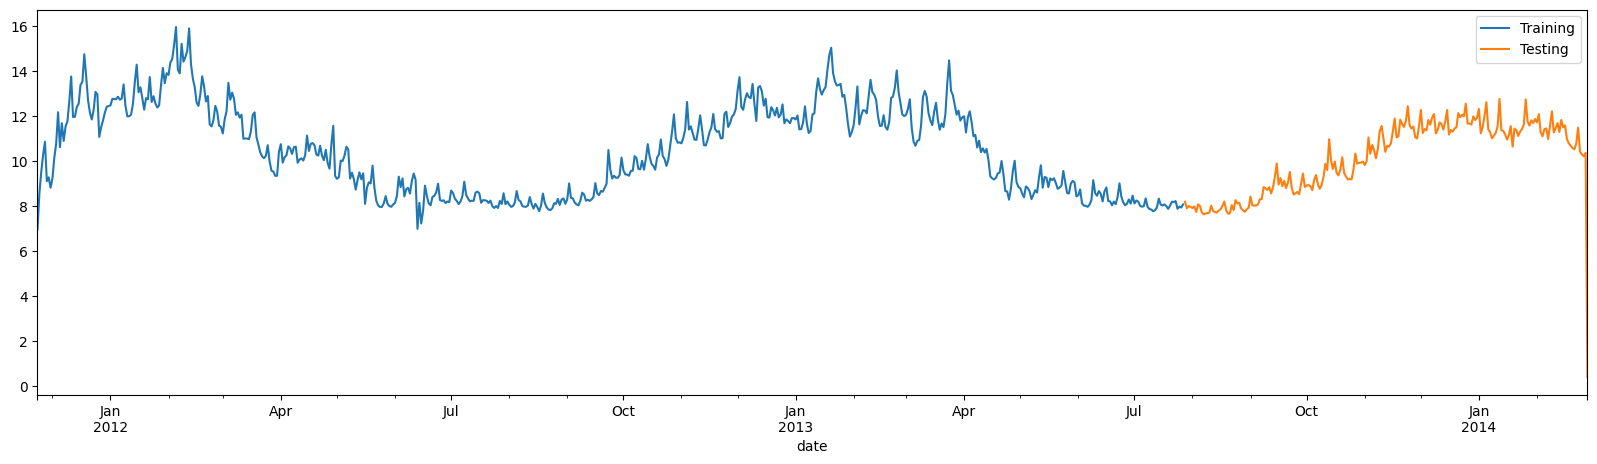

In [7]:
figure, ax = plt.subplots(figsize=(20, 5))
training_data.plot(ax=ax, label="Training", x="date", y="consumption")
testing_data.plot(ax=ax, label="Testing", x="date", y="consumption")
plt.show()

In [8]:
# Dropping unnecessary `date` column
training_data = training_data.drop(columns=["date"])
testing_dates = testing_data["date"]
testing_data = testing_data.drop(columns=["date"])

X_train = training_data[["day_of_week", "day_of_year", "month", "quarter", "year"]]
y_train = training_data["consumption"]

X_test = testing_data[["day_of_week", "day_of_year", "month", "quarter", "year"]]
y_test = testing_data["consumption"]

In [11]:
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# XGBoost
cv_split = TimeSeriesSplit(n_splits=4, test_size=100)
model = XGBRegressor()
parameters = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05],
    "n_estimators": [100, 300],
    "colsample_bytree": [0.3]
}


grid_search = GridSearchCV(estimator=model, cv=cv_split, param_grid=parameters)
grid_search.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.3], 'learning_rate': [0.01, 0.05], 'max_depth': [3, 4, ...], 'n_estimators': [100, 300]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...test_size=100)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [12]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,\
  mean_squared_error

def evaluate_model(y_test, prediction):
  print(f"MAE: {mean_absolute_error(y_test, prediction)}")
  print(f"MSE: {mean_squared_error(y_test, prediction)}")
  print(f"MAPE: {mean_absolute_percentage_error(y_test, prediction)}")

def plot_predictions(testing_dates, y_test, prediction):
  df_test = pd.DataFrame({"date": testing_dates, "actual": y_test, "prediction": prediction })
  figure, ax = plt.subplots(figsize=(10, 5))
  df_test.plot(ax=ax, label="Actual", x="date", y="actual")
  df_test.plot(ax=ax, label="Prediction", x="date", y="prediction")
  plt.legend(["Actual", "Prediction"])
  plt.show()

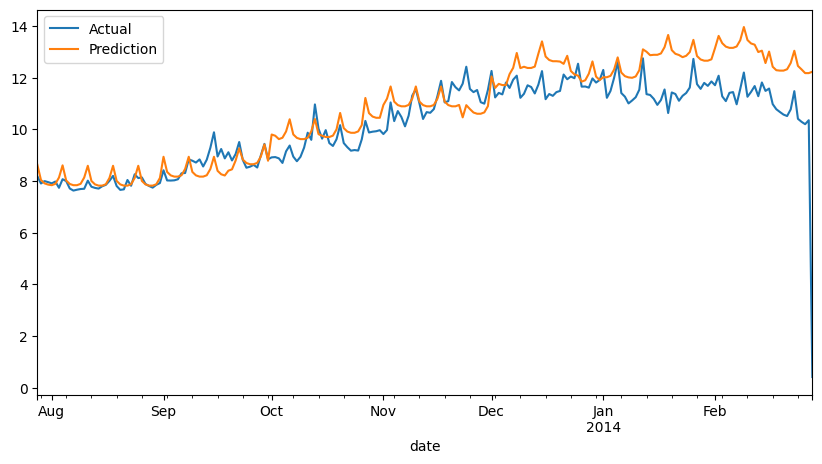

MAE: 0.7730692856263396
MSE: 1.5266765332362597
MAPE: 0.19845614180071733


In [13]:
# Evaluating GridSearch results
prediction = grid_search.predict(X_test)
plot_predictions(testing_dates, y_test, prediction)
evaluate_model(y_test, prediction)

In [14]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# XGBoost
cv_split = TimeSeriesSplit(n_splits=4, test_size=100)
model = GradientBoostingRegressor()
parameters = {
    "max_features": [3, 4, 5],
    "learning_rate": [0.01, 0.05],
    "n_estimators": [100, 300]
}


grid_search = GridSearchCV(estimator=model, cv=cv_split, param_grid=parameters)
grid_search.fit(X_train, y_train)


,estimator,GradientBoostingRegressor()
,param_grid,"{'learning_rate': [0.01, 0.05], 'max_features': [3, 4, ...], 'n_estimators': [100, 300]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...test_size=100)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


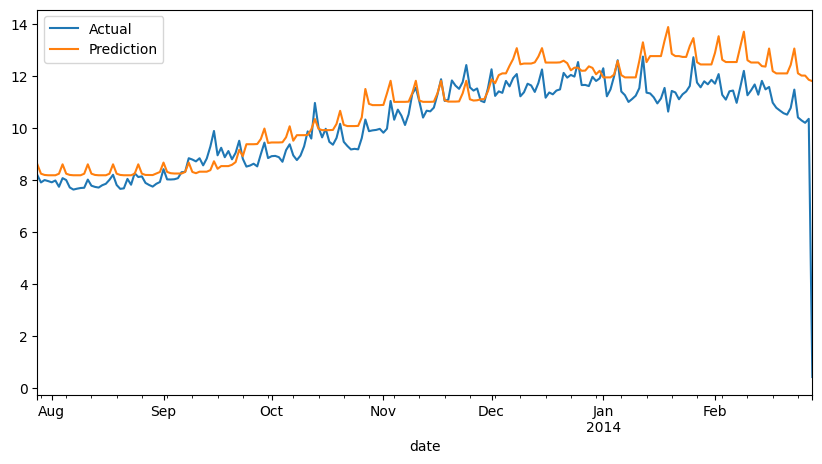

MAE: 0.7557559891536486
MSE: 1.3304305650445665
MAPE: 0.19414684728282297


In [15]:
# Evaluating GridSearch results
prediction = grid_search.predict(X_test)
plot_predictions(testing_dates, y_test, prediction)
evaluate_model(y_test, prediction)

In [16]:
print(prediction)

[ 8.60527963  8.24482225  8.19624871  8.1842473   8.1842473   8.1842473
  8.2432349   8.60527963  8.24482225  8.19624871  8.1842473   8.1842473
  8.1842473   8.2432349   8.60527963  8.24482225  8.19624871  8.1842473
  8.1842473   8.1842473   8.2432349   8.60527963  8.24482225  8.19624871
  8.1842473   8.1842473   8.1842473   8.2432349   8.60527963  8.24482225
  8.19624871  8.19236737  8.19236737  8.25139593  8.31038353  8.67242826
  8.31197088  8.26339733  8.25139593  8.25139593  8.25139593  8.31038353
  8.67242826  8.31197088  8.26339733  8.321873    8.321873    8.321873
  8.3808606   8.72283516  8.43352355  8.53688514  8.53688514  8.53688514
  8.58683002  8.68983339  9.16306232  8.92022331  9.37875216  9.37875216
  9.37875216  9.38637458  9.57940656  9.98183614  9.42732571  9.44669162
  9.44669162  9.44669162  9.45431403  9.64734601 10.06985831  9.51402459
  9.72706819  9.72706819  9.72706819  9.7346906   9.94876396 10.34842993
  9.97032231  9.92174877  9.92174877  9.92174877  9.9293

In [17]:
print(X_test)

     day_of_week  day_of_year  month  quarter  year
613            6          209      7        3  2013
614            0          210      7        3  2013
615            1          211      7        3  2013
616            2          212      7        3  2013
617            3          213      8        3  2013
..           ...          ...    ...      ...   ...
824            0           55      2        1  2014
825            1           56      2        1  2014
826            2           57      2        1  2014
827            3           58      2        1  2014
828            4           59      2        1  2014

[216 rows x 5 columns]


In [18]:
# Initialize data to lists.
data = [{'day_of_week': 6, 'day_of_year': 209, 'month': 7, 'quarter': 3, 'year':2013}]

# Creates DataFrame.
df = pd.DataFrame(data)
prediction = grid_search.predict(df)
print(prediction)

[8.60527963]
